# Flight Delay Dataset — Python EDA
### Numbers, correlations, and cutting the fat before modeling

## Setup

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(30)

polars.config.Config

## 1. Load + Sanity Check

In [2]:
df = pl.read_csv("../data/flightsData1m.csv")
print(df.shape)
df.head()

(1000000, 61)


FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
str,str,str,str,bool,bool,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,str,str,i64,str,i64,str,i64,str,str,i64,i64,i64,i64,str,str,i64,str,i64,i64,i64,i64,str,str,i64,str,i64,f64,f64,str,f64,f64,f64,f64,i64,f64,f64,f64,str,i64,i64
"""2022-01-30""","""Alaska Airlines Inc.""","""BUR""","""SEA""",false,false,700,648.0,0.0,-12.0,927.0,0.0,133.0,165.0,159.0,937.0,2022,1,1,30,7,"""AS""","""AS""",19930,"""AS""",961,"""AS""",19930,"""AS""","""N238AK""",961,10800,1080003,32575,"""Burbank, CA""","""CA""",6,"""California""",91,14747,1474703,30559,"""Seattle, WA""","""WA""",53,"""Washington""",93,0.0,-1.0,"""0700-0759""",15.0,703.0,916.0,11.0,945,-18.0,0.0,-2.0,"""0900-0959""",4,0
"""2022-07-10""","""Delta Air Lines Inc.""","""LAX""","""DFW""",false,false,845,920.0,35.0,35.0,1422.0,22.0,159.0,195.0,182.0,1235.0,2022,3,7,10,7,"""DL""","""DL""",19790,"""DL""",1041,"""DL""",19790,"""DL""","""N367NW""",1041,12892,1289208,32575,"""Los Angeles, CA""","""CA""",6,"""California""",91,11298,1129806,30194,"""Dallas/Fort Worth, TX""","""TX""",48,"""Texas""",74,1.0,2.0,"""0800-0859""",13.0,933.0,1412.0,10.0,1400,22.0,1.0,1.0,"""1400-1459""",5,0
"""2022-03-25""","""Southwest Airlines Co.""","""DAL""","""DEN""",false,false,915,930.0,15.0,15.0,1027.0,7.0,104.0,125.0,117.0,651.0,2022,1,3,25,5,"""WN""","""WN""",19393,"""WN""",825,"""WN""",19393,"""WN""","""N7888A""",825,11259,1125904,30194,"""Dallas, TX""","""TX""",48,"""Texas""",74,11292,1129202,30325,"""Denver, CO""","""CO""",8,"""Colorado""",82,1.0,1.0,"""0900-0959""",9.0,939.0,1023.0,4.0,1020,7.0,0.0,0.0,"""1000-1059""",3,0
"""2022-06-04""","""American Airlines Inc.""","""SJU""","""PHL""",false,false,1320,1318.0,0.0,-2.0,1707.0,0.0,203.0,243.0,229.0,1576.0,2022,2,6,4,6,"""AA""","""AA""",19805,"""AA""",1496,"""AA""",19805,"""AA""","""N928AM""",1496,14843,1484306,34819,"""San Juan, PR""","""PR""",72,"""Puerto Rico""",3,14100,1410005,34100,"""Philadelphia, PA""","""PA""",42,"""Pennsylvania""",23,0.0,-1.0,"""1300-1359""",20.0,1338.0,1701.0,6.0,1723,-16.0,0.0,-2.0,"""1700-1759""",7,0
"""2022-01-21""","""American Airlines Inc.""","""PHX""","""LAS""",false,false,1552,1545.0,0.0,-7.0,1557.0,0.0,49.0,71.0,72.0,255.0,2022,1,1,21,5,"""AA""","""AA""",19805,"""AA""",1541,"""AA""",19805,"""AA""","""N405AN""",1541,14107,1410702,30466,"""Phoenix, AZ""","""AZ""",4,"""Arizona""",81,12889,1288903,32211,"""Las Vegas, NV""","""NV""",32,"""Nevada""",85,0.0,-1.0,"""1500-1559""",14.0,1559.0,1548.0,9.0,1603,-6.0,0.0,-1.0,"""1600-1659""",2,0


In [3]:
df.schema

Schema([('FlightDate', String),
        ('Airline', String),
        ('Origin', String),
        ('Dest', String),
        ('Cancelled', Boolean),
        ('Diverted', Boolean),
        ('CRSDepTime', Int64),
        ('DepTime', Float64),
        ('DepDelayMinutes', Float64),
        ('DepDelay', Float64),
        ('ArrTime', Float64),
        ('ArrDelayMinutes', Float64),
        ('AirTime', Float64),
        ('CRSElapsedTime', Float64),
        ('ActualElapsedTime', Float64),
        ('Distance', Float64),
        ('Year', Int64),
        ('Quarter', Int64),
        ('Month', Int64),
        ('DayofMonth', Int64),
        ('DayOfWeek', Int64),
        ('Marketing_Airline_Network', String),
        ('Operated_or_Branded_Code_Share_Partners', String),
        ('DOT_ID_Marketing_Airline', Int64),
        ('IATA_Code_Marketing_Airline', String),
        ('Flight_Number_Marketing_Airline', Int64),
        ('Operating_Airline', String),
        ('DOT_ID_Operating_Airline', Int64),
        

In [4]:
null_counts = df.null_count().transpose(include_header=True, header_name="column", column_names=["null_count"])
null_counts = null_counts.with_columns((pl.col("null_count") / df.height * 100).alias("null_pct")).sort("null_pct", descending=True)
print(null_counts)

shape: (61, 3)
┌──────────────────────┬────────────┬──────────┐
│ column               ┆ null_count ┆ null_pct │
│ ---                  ┆ ---        ┆ ---      │
│ str                  ┆ u32        ┆ f64      │
╞══════════════════════╪════════════╪══════════╡
│ ArrDelayMinutes      ┆ 32974      ┆ 3.2974   │
│ AirTime              ┆ 32974      ┆ 3.2974   │
│ ActualElapsedTime    ┆ 32974      ┆ 3.2974   │
│ ArrDelay             ┆ 32974      ┆ 3.2974   │
│ ArrDel15             ┆ 32974      ┆ 3.2974   │
│ ArrivalDelayGroups   ┆ 32974      ┆ 3.2974   │
│ WheelsOn             ┆ 30712      ┆ 3.0712   │
│ TaxiIn               ┆ 30712      ┆ 3.0712   │
│ ArrTime              ┆ 30711      ┆ 3.0711   │
│ TaxiOut              ┆ 30301      ┆ 3.0301   │
│ WheelsOff            ┆ 30301      ┆ 3.0301   │
│ DepDelayMinutes      ┆ 29771      ┆ 2.9771   │
│ DepDelay             ┆ 29771      ┆ 2.9771   │
│ DepDel15             ┆ 29771      ┆ 2.9771   │
│ DepartureDelayGroups ┆ 29771      ┆ 2.9771   │
│ …  

**Findings:** arrival outcome fields (`ArrDelay`, `ArrDelayMinutes`, `AirTime`, `ActualElapsedTime`, `ArrDel15`, and `ArrivalDelayGroups`) share 32,974 nulls (3.30%), while departure-delay fields have 29,771 nulls (2.98%). The different stages explain the staggered missingness: some flights have departure information but no completed arrival outcome. Rows without `ArrDelay` cannot supply the classification target and are excluded only when the modeling frame is created.

## 2. Distribution Check

### 2.1 DepDelay

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 970229.0  │
│ null_count ┆ 29771.0   │
│ mean       ┆ 13.107069 │
│ std        ┆ 53.851709 │
│ min        ┆ -55.0     │
│ 25%        ┆ -5.0      │
│ 50%        ┆ -2.0      │
│ 75%        ┆ 11.0      │
│ max        ┆ 7223.0    │
└────────────┴───────────┘


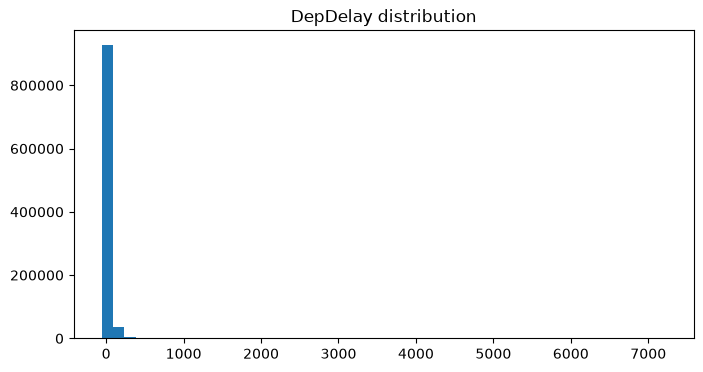

In [5]:
print(df["DepDelay"].describe())

plt.figure(figsize=(8,4))
plt.hist(df["DepDelay"].drop_nulls().to_numpy(), bins=50)
plt.title("DepDelay distribution")
plt.show()

**Findings:** mean 13.1 min, but median is **-2 min** — over half of all flights depart early or exactly on time. The mean is inflated by a long right tail of severe outliers (max 7223 min before the >720min outlier drop). This gap between mean and median is the clearest sign of the skew confirmed numerically in 2.3.

### 2.2 ArrDelay, TaxiOut, TaxiIn, Distance

--- ArrDelay ---
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 967026.0 │
│ null_count ┆ 32974.0  │
│ mean       ┆ 7.556112 │
│ std        ┆ 55.78662 │
│ min        ┆ -81.0    │
│ 25%        ┆ -14.0    │
│ 50%        ┆ -5.0     │
│ 75%        ┆ 10.0     │
│ max        ┆ 7232.0   │
└────────────┴──────────┘


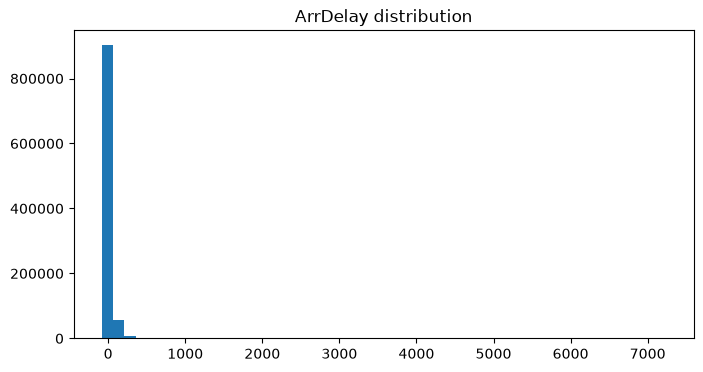

--- TaxiOut ---
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 969699.0  │
│ null_count ┆ 30301.0   │
│ mean       ┆ 16.974758 │
│ std        ┆ 9.519112  │
│ min        ┆ 1.0       │
│ 25%        ┆ 11.0      │
│ 50%        ┆ 15.0      │
│ 75%        ┆ 19.0      │
│ max        ┆ 221.0     │
└────────────┴───────────┘


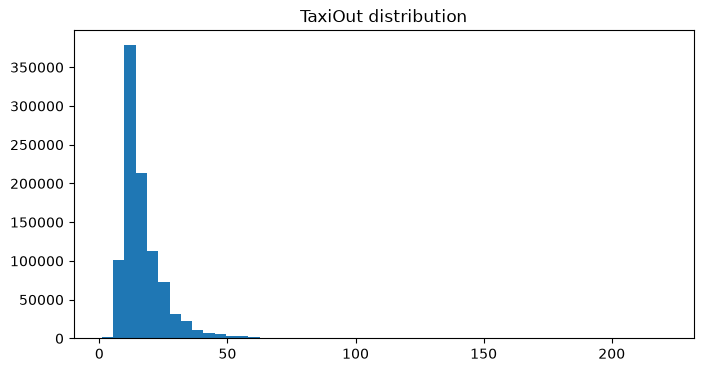

--- TaxiIn ---
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 969288.0 │
│ null_count ┆ 30712.0  │
│ mean       ┆ 7.888183 │
│ std        ┆ 6.638009 │
│ min        ┆ 1.0      │
│ 25%        ┆ 4.0      │
│ 50%        ┆ 6.0      │
│ 75%        ┆ 9.0      │
│ max        ┆ 280.0    │
└────────────┴──────────┘


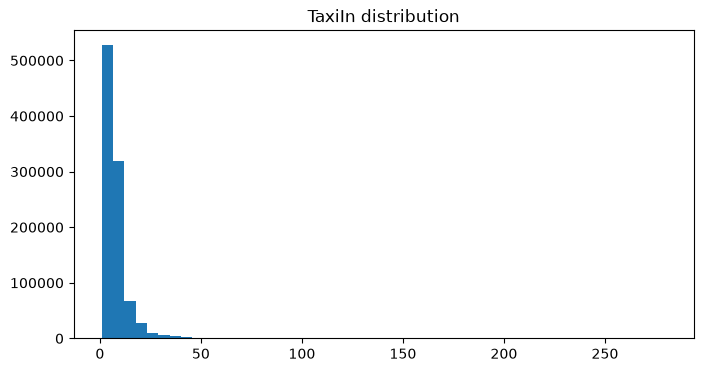

--- Distance ---
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 1e6        │
│ null_count ┆ 0.0        │
│ mean       ┆ 797.751118 │
│ std        ┆ 591.538886 │
│ min        ┆ 31.0       │
│ 25%        ┆ 368.0      │
│ 50%        ┆ 643.0      │
│ 75%        ┆ 1035.0     │
│ max        ┆ 5095.0     │
└────────────┴────────────┘


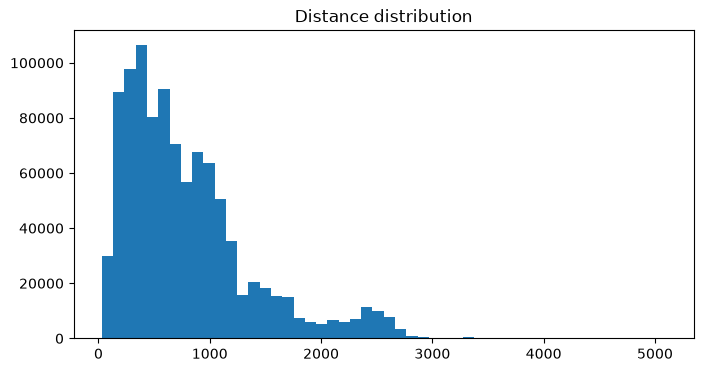

In [6]:
for col in ["ArrDelay", "TaxiOut", "TaxiIn", "Distance"]:
    print(f"--- {col} ---")
    print(df[col].describe())
    plt.figure(figsize=(8,4))
    plt.hist(df[col].drop_nulls().to_numpy(), bins=50)
    plt.title(f"{col} distribution")
    plt.show()

**Findings:**
- `ArrDelay`: same pattern as DepDelay — mean 7.6, median -5, most flights arrive early.
- `TaxiOut`: mean ~17 min, tighter spread (std 9.5) than delay columns — ground taxi time is far more consistent than delay.
- `TaxiIn`: mean ~7.9 min, similarly tight.
- `Distance`: mean ~798 mi, wide range (31 to 5095 mi) but much less extreme skew than the delay columns.

### 2.3 Skewness

In [7]:
for col in ["DepDelay", "ArrDelay", "TaxiOut", "TaxiIn", "Distance"]:
    print(col, "skew:", df[col].skew())

DepDelay skew: 13.015124704878241
ArrDelay skew: 11.842055962675982
TaxiOut skew: 3.695566546298071
TaxiIn skew: 5.046048454288033
Distance skew: 1.5491250580785338


**Findings:** `DepDelay` (13.0) and `ArrDelay` (11.8) are extremely right-skewed — far beyond typical "skewed" data. `TaxiOut`/`TaxiIn` are moderately skewed (3.7 / 5.0). `Distance` is only mildly skewed (1.5). Confirms delay columns need special handling (capping, log-transform, or bucketing into risk classes) before they'd work well in a linear model — tree-based models handle this skew natively, which is one more reason a RandomForest/LightGBM approach fits better here than linear regression.

### 2.4 Mean vs Median (outlier pull check)

In [8]:
for col in ["DepDelay", "ArrDelay"]:
    print(col, "mean:", df[col].mean(), "median:", df[col].median())

DepDelay mean: 13.107068537427763 median: -2.0
ArrDelay mean: 7.5561122451723115 median: -5.0


**Findings:** confirms 2.1 — for both delay columns, mean is meaningfully higher than median, meaning a "typical" flight is on-time-or-early, and the average is being pulled upward by a relatively small number of severely delayed flights.

### 2.5 Categorical distributions

In [9]:
print(df["Airline"].value_counts().sort("count", descending=True))
print(df["Cancelled"].value_counts())
print(df["Diverted"].value_counts())

shape: (21, 2)
┌─────────────────────────────────┬────────┐
│ Airline                         ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Southwest Airlines Co.          ┆ 179693 │
│ Delta Air Lines Inc.            ┆ 125325 │
│ American Airlines Inc.          ┆ 121648 │
│ SkyWest Airlines Inc.           ┆ 108336 │
│ United Air Lines Inc.           ┆ 86128  │
│ Republic Airlines               ┆ 48220  │
│ JetBlue Airways                 ┆ 38544  │
│ Envoy Air                       ┆ 36867  │
│ Endeavor Air Inc.               ┆ 35049  │
│ Comair Inc.                     ┆ 33103  │
│ Alaska Airlines Inc.            ┆ 31805  │
│ Spirit Air Lines                ┆ 31687  │
│ Frontier Airlines Inc.          ┆ 21279  │
│ Allegiant Air                   ┆ 18211  │
│ Mesa Airlines Inc.              ┆ 17448  │
│ Horizon Air                     ┆ 13758  │
│ Capital Cargo International     ┆ 1316

**Findings:** Airline volume ranges from Southwest (~180K) down to GoJet (~8K) — matches SQL Category 1 findings, no surprises. `Cancelled` and `Diverted` are both heavily imbalanced (small minority `true`) — expected, and important to remember if either becomes a classification target later: will need class weighting or resampling.

## 3. Outlier Audit (no outcome-based filtering)

In [10]:
# Audit the SQL outlier rule, but do not filter the Python modeling population
# using DepDelay: it is unavailable at the required pre-flight prediction time.
extreme_dep_delay_rows = df.filter(pl.col("DepDelay") > 720).height
print(
    f"DepDelay > 720 minutes: {extreme_dep_delay_rows:,} rows "
    f"({extreme_dep_delay_rows / df.height:.3%}) — flagged, not dropped"
)

DepDelay > 720 minutes: 1,026 rows (0.103%) — flagged, not dropped


**Result:** 1,026 rows (0.103%) have departure delay above 12 hours, matching the SQL audit. They are **not used to filter this notebook's model**, because selecting rows using `DepDelay` would condition a pre-flight model on information that does not exist at prediction time. Tree-based models do not require outcome-based outlier deletion from the allowed schedule features.

## 4. Feature-Feature Correlation (find redundant columns)

In [11]:
numeric_cols = [
    c for c, dt in df.schema.items()
    if dt in (pl.Int64, pl.Int32, pl.Float64, pl.Float32)
]

# Constants have undefined correlation and caused avoidable NaN warnings.
corr_numeric_cols = [c for c in numeric_cols if df[c].drop_nulls().n_unique() > 1]
print(corr_numeric_cols)

['CRSDepTime', 'DepTime', 'DepDelayMinutes', 'DepDelay', 'ArrTime', 'ArrDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime', 'Distance', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'DOT_ID_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'DOT_ID_Operating_Airline', 'Flight_Number_Operating_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginStateFips', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestStateFips', 'DestWac', 'DepDel15', 'DepartureDelayGroups', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrDelay', 'ArrDel15', 'ArrivalDelayGroups', 'DistanceGroup', 'DivAirportLandings']


In [12]:
corr_df = df.select(corr_numeric_cols).drop_nulls()
corr_matrix = np.corrcoef(corr_df.to_numpy(), rowvar=False)
corr_pl = pl.DataFrame(corr_matrix, schema=corr_numeric_cols)
corr_pl

C:\Users\shiva\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\shiva\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Quarter,Month,DayofMonth,DayOfWeek,DOT_ID_Marketing_Airline,Flight_Number_Marketing_Airline,DOT_ID_Operating_Airline,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginStateFips,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestStateFips,DestWac,DepDel15,DepartureDelayGroups,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,DistanceGroup,DivAirportLandings
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.946348,0.094712,0.100978,0.573107,0.08519,-0.008902,-0.013779,-0.010618,-0.001975,0.001573,0.003081,-0.000661,0.001441,0.0149,-0.010838,0.004369,-0.010843,-0.033042,-0.033042,-0.063242,-0.015439,-0.006087,0.026791,0.02679,0.067007,0.007328,0.018335,0.186656,0.149158,-0.000867,0.916624,0.606754,-0.019953,0.684615,0.101293,0.160598,0.139575,-0.003276,NaN
0.946348,1.0,0.11642,0.124323,0.603435,0.106782,-0.015138,-0.020076,-0.015252,-0.01136,0.001247,0.002792,-0.001948,0.003676,0.00641,-0.006498,0.000314,-0.0065,-0.033726,-0.033725,-0.062213,-0.011201,-0.012487,0.026676,0.026675,0.064443,0.004567,0.021698,0.231716,0.200251,0.008433,0.968032,0.638215,-0.017692,0.690036,0.125922,0.201959,0.188982,-0.012624,NaN
0.094712,0.11642,1.0,0.997959,0.011394,0.980718,0.0158,0.017443,0.022547,0.015374,0.018815,0.021973,-0.011782,0.029606,0.034714,-0.011921,0.015411,-0.011847,-0.013162,-0.013162,-0.007621,0.002276,-0.028842,-0.005302,-0.005302,-0.001197,0.003664,-0.028031,0.523558,0.801532,0.043853,0.107671,0.017667,0.014846,0.071909,0.967097,0.490628,0.756789,0.016055,NaN
0.100978,0.124323,0.997959,1.0,0.016302,0.97754,0.020873,0.022149,0.027129,0.020828,0.021492,0.02574,-0.012012,0.032218,0.024003,-0.021268,0.000116,-0.021194,-0.015184,-0.015184,-0.012649,-0.000461,-0.025998,-0.004827,-0.004827,-0.000127,0.00089,-0.025401,0.542655,0.815459,0.043925,0.115317,0.023103,0.010875,0.07708,0.968892,0.506384,0.768713,0.021525,NaN
0.573107,0.603435,0.011394,0.016302,1.0,0.012074,0.012635,0.009379,0.016413,0.007468,-0.021202,-0.023916,-0.002948,-0.002468,0.008049,0.017594,0.017962,0.017593,-0.006627,-0.006627,-0.04028,-0.003646,0.008727,0.015475,0.015474,0.038437,0.012732,0.020459,0.085696,0.041829,0.023213,0.625845,0.959961,0.011325,0.821431,0.024737,0.075061,0.047258,0.010659,NaN
0.08519,0.106782,0.980718,0.97754,0.012074,1.0,0.019667,0.011325,0.046786,0.010132,0.018118,0.021296,-0.012156,0.029075,0.048268,-0.004207,0.033009,-0.004134,-0.0121,-0.0121,-0.004075,0.005768,-0.036042,-0.006824,-0.006824,-0.000923,0.006072,-0.035995,0.480672,0.770928,0.148633,0.101221,0.018414,0.086731,0.068729,0.986581,0.523781,0.784202,0.010886,NaN
-0.008902,-0.015138,0.0158,0.020873,0.012635,0.019667,1.0,0.989428,0.986816,0.984892,-0.015687,-0.016765,-0.002516,0.008743,0.150543,-0.370421,-0.110047,-0.370422,0.060799,0.060799,0.014239,-0.056752,-0.024824,0.093962,0.093963,0.015364,-0.083647,0.059356,0.031939,0.031853,0.048132,-0.025662,0.015394,0.075521,0.024562,0.014591,0.043795,0.025651,0.972911,NaN
-0.013779,-0.020076,0.017443,0.022149,0.009379,0.011325,0.989428,1.0,0.981575,0.982215,-0.024439,-0.027293,-0.002467,0.008876,0.166469,-0.34729,-0.08084,-0.347291,0.057078,0.057079,0.011796,-0.044516,-0.042344,0.0854,0.0854,0.003128,-0.078599,0.050545,0.030444,0.03228,0.073753,-0.029759,0.011728,0.09357,0.022459,-0.004568,0.021005,-0.000723,0.97025,NaN
-0.010618,-0.015252,0.022547,0.027129,0.016413,0.046786,0.986816,0.981575,1.0,0.969153,-0.017394,-0.019091,-0.003523,0.010653,0.180405,-0.343364,-0.065268,-0.343366,0.057303,0.057303,0.014341,-0.044159,-0.045669,0.08493,0.08493,0.006161,-0.075511,0.042087,0.035497,0.038808,0.180613,-0.02207,0.01941,0.167821,0.027381,0.04774,0.086083,0.070065,0.957217,NaN


In [13]:
# Flag pairs with |correlation| > 0.9 (excluding self-correlation)
threshold = 0.9
redundant_pairs = []
for i, col_i in enumerate(corr_numeric_cols):
    for j, col_j in enumerate(corr_numeric_cols):
        if i < j and abs(corr_matrix[i, j]) > threshold:
            redundant_pairs.append((col_i, col_j, round(corr_matrix[i, j], 3)))

for pair in redundant_pairs:
    print(pair)

('CRSDepTime', 'DepTime', np.float64(0.946))
('CRSDepTime', 'WheelsOff', np.float64(0.917))
('DepTime', 'WheelsOff', np.float64(0.968))
('DepDelayMinutes', 'DepDelay', np.float64(0.998))
('DepDelayMinutes', 'ArrDelayMinutes', np.float64(0.981))
('DepDelayMinutes', 'ArrDelay', np.float64(0.967))
('DepDelay', 'ArrDelayMinutes', np.float64(0.978))
('DepDelay', 'ArrDelay', np.float64(0.969))
('ArrTime', 'WheelsOn', np.float64(0.96))
('ArrDelayMinutes', 'ArrDelay', np.float64(0.987))
('AirTime', 'CRSElapsedTime', np.float64(0.989))
('AirTime', 'ActualElapsedTime', np.float64(0.987))
('AirTime', 'Distance', np.float64(0.985))
('AirTime', 'DistanceGroup', np.float64(0.973))
('CRSElapsedTime', 'ActualElapsedTime', np.float64(0.982))
('CRSElapsedTime', 'Distance', np.float64(0.982))
('CRSElapsedTime', 'DistanceGroup', np.float64(0.97))
('ActualElapsedTime', 'Distance', np.float64(0.969))
('ActualElapsedTime', 'DistanceGroup', np.float64(0.957))
('Distance', 'DistanceGroup', np.float64(0.986))
(

**Findings:** several near-duplicate columns are confirmed:

- `DepDelayMinutes` ↔ `DepDelay` — the minutes version clips negative values to zero.
- `ArrDelayMinutes` ↔ `ArrDelay` and `ArrivalDelayGroups` ↔ `ArrDelay` — direct target transformations.
- `CRSDepTime` ↔ actual `DepTime`/`WheelsOff` and scheduled duration ↔ actual duration fields — high correlation does not make the actual fields available before departure.
- `Distance` ↔ `DistanceGroup` — keep the continuous version.

Correlation is descriptive here, not permission to use a field. Section 7 enforces the pre-flight feature contract explicitly.

## 5. Feature-Target Correlation

**Target:** `ArrDelay` (continuous). Before reading the ranking below — a critical catch first.

In [14]:
target = "ArrDelay"
target_corr = {}
for col in numeric_cols:
    if col == target:
        continue
    sub = df.select([col, target]).drop_nulls()
    if sub.height > 0:
        c = np.corrcoef(sub[col].to_numpy(), sub[target].to_numpy())[0, 1]
        target_corr[col] = round(c, 3)

target_corr_sorted = dict(sorted(target_corr.items(), key=lambda x: abs(x[1]), reverse=True))
for k, v in target_corr_sorted.items():
    print(k, v)

ArrDelayMinutes 0.987
DepDelay 0.969
DepDelayMinutes 0.967
Year nan
ArrivalDelayGroups 0.831
DepartureDelayGroups 0.793
ArrDel15 0.571
DepDel15 0.529
TaxiOut 0.18
DepTime 0.126
WheelsOff 0.121
TaxiIn 0.106
CRSDepTime 0.101
CRSArrTime 0.08
ActualElapsedTime 0.048
DOT_ID_Marketing_Airline 0.041
Month 0.035
DestWac -0.035
DayOfWeek 0.033
WheelsOn 0.032
Quarter 0.03
OriginWac -0.029
ArrTime 0.025
DOT_ID_Operating_Airline 0.02
AirTime 0.015
Flight_Number_Marketing_Airline -0.015
Flight_Number_Operating_Airline -0.015
OriginAirportID -0.014
OriginAirportSeqID -0.014
DayofMonth -0.013
OriginCityMarketID -0.009
CRSElapsedTime -0.005
DestAirportID -0.005
DestAirportSeqID -0.005
DestStateFips 0.005
DestCityMarketID 0.004
DistanceGroup 0.002
Distance 0.001
OriginStateFips 0.0
DivAirportLandings nan


**Data leakage warning:** the top-correlated fields are direct target transformations or actual operational outcomes. `ArrDelayMinutes`, `ArrDel15`, and `ArrivalDelayGroups` encode the target itself. `DepDelay`, `DepDelayMinutes`, actual `DepTime`, taxi/wheel times, air time, and actual elapsed/arrival times exist only after the prediction cutoff.

**Every one of those fields is excluded from Section 7.** `ArrDelay` appears only long enough to derive the target label; it is never present in the model matrix.

## 6. Categorical Feature Relevance

In [15]:
categorical_check_cols = ["Airline", "Origin", "Dest", "DepTimeBlk", "DayOfWeek"]

for col in categorical_check_cols:
    print(f"--- avg {target} by {col} (top 10) ---")
    result = (
        df
        .filter(pl.col(target).is_not_null())
        .group_by(col)
        .agg([pl.len().alias("count"), pl.col(target).mean().alias("avg_target")])
        .filter(pl.col("count") > 200)
        .sort("avg_target", descending=True)
        .head(10)
    )
    print(result)

--- avg ArrDelay by Airline (top 10) ---


shape: (10, 3)
┌─────────────────────────────────┬────────┬────────────┐
│ Airline                         ┆ count  ┆ avg_target │
│ ---                             ┆ ---    ┆ ---        │
│ str                             ┆ u32    ┆ f64        │
╞═════════════════════════════════╪════════╪════════════╡
│ Allegiant Air                   ┆ 17468  ┆ 20.295455  │
│ JetBlue Airways                 ┆ 36540  ┆ 20.142994  │
│ Frontier Airlines Inc.          ┆ 20601  ┆ 17.323479  │
│ GoJet Airlines, LLC d/b/a Unit… ┆ 7854   ┆ 12.886937  │
│ Spirit Air Lines                ┆ 30574  ┆ 12.529241  │
│ Comair Inc.                     ┆ 31697  ┆ 9.667476   │
│ American Airlines Inc.          ┆ 116666 ┆ 9.461917   │
│ Mesa Airlines Inc.              ┆ 16688  ┆ 9.045721   │
│ Commutair Aka Champlain Enterp… ┆ 10493  ┆ 8.113409   │
│ Southwest Airlines Co.          ┆ 174755 ┆ 7.123253   │
└─────────────────────────────────┴────────┴────────────┘
--- avg ArrDelay by Origin (top 10) ---


shape: (10, 3)
┌────────┬───────┬────────────┐
│ Origin ┆ count ┆ avg_target │
│ ---    ┆ ---   ┆ ---        │
│ str    ┆ u32   ┆ f64        │
╞════════╪═══════╪════════════╡
│ HHH    ┆ 306   ┆ 27.297386  │
│ PGD    ┆ 981   ┆ 25.944954  │
│ ASE    ┆ 946   ┆ 22.846723  │
│ EYW    ┆ 1233  ┆ 22.188159  │
│ BQN    ┆ 320   ┆ 21.596875  │
│ PBI    ┆ 3484  ┆ 20.726751  │
│ MOT    ┆ 334   ┆ 20.565868  │
│ FNT    ┆ 503   ┆ 19.628231  │
│ PIE    ┆ 1194  ┆ 19.473199  │
│ TTN    ┆ 333   ┆ 18.084084  │
└────────┴───────┴────────────┘
--- avg ArrDelay by Dest (top 10) ---
shape: (10, 3)
┌──────┬───────┬────────────┐
│ Dest ┆ count ┆ avg_target │
│ ---  ┆ ---   ┆ ---        │
│ str  ┆ u32   ┆ f64        │
╞══════╪═══════╪════════════╡
│ PGD  ┆ 982   ┆ 39.361507  │
│ BQN  ┆ 331   ┆ 28.76435   │
│ TTN  ┆ 351   ┆ 23.94302   │
│ PIE  ┆ 1199  ┆ 23.664721  │
│ SFB  ┆ 1339  ┆ 23.318895  │
│ ASE  ┆ 972   ┆ 22.5       │
│ LNK  ┆ 272   ┆ 20.555147  │
│ PBI  ┆ 3666  ┆ 19.121113  │
│ AZA  ┆ 890   ┆ 17.132584  │


shape: (10, 3)
┌────────────┬───────┬────────────┐
│ DepTimeBlk ┆ count ┆ avg_target │
│ ---        ┆ ---   ┆ ---        │
│ str        ┆ u32   ┆ f64        │
╞════════════╪═══════╪════════════╡
│ 1900-1959  ┆ 50210 ┆ 16.045031  │
│ 2000-2059  ┆ 44406 ┆ 15.655294  │
│ 2100-2159  ┆ 31309 ┆ 15.321729  │
│ 2200-2259  ┆ 25043 ┆ 14.077467  │
│ 1800-1859  ┆ 57859 ┆ 13.913687  │
│ 1700-1759  ┆ 59762 ┆ 13.71348   │
│ 1600-1659  ┆ 54953 ┆ 12.434062  │
│ 1500-1559  ┆ 56180 ┆ 11.521289  │
│ 2300-2359  ┆ 7562  ┆ 10.253637  │
│ 1400-1459  ┆ 56088 ┆ 9.577699   │
└────────────┴───────┴────────────┘
--- avg ArrDelay by DayOfWeek (top 10) ---
shape: (7, 3)
┌───────────┬────────┬────────────┐
│ DayOfWeek ┆ count  ┆ avg_target │
│ ---       ┆ ---    ┆ ---        │
│ i64       ┆ u32    ┆ f64        │
╞═══════════╪════════╪════════════╡
│ 5         ┆ 143370 ┆ 11.194762  │
│ 7         ┆ 143927 ┆ 9.351532   │
│ 4         ┆ 142287 ┆ 9.186813   │
│ 6         ┆ 125995 ┆ 9.121783   │
│ 1         ┆ 142379 ┆ 7.493

**Findings:** Airline ranking (Allegiant, JetBlue, Frontier worst) matches SQL Category 1 exactly — good cross-validation between the two layers. These categorical groupings are genuinely useful, unlike most of Section 5's numeric ranking — `Airline`, `Origin`, `Dest`, and time-of-day (`DepTimeBlk`) are all known before a flight and all show real variation in average delay, making them strong candidate features.

## 7. Pre-flight delay-risk model

### Prediction contract

The user supplies route and schedule information **before departure**. Model inputs are therefore restricted to:

- scheduled departure/arrival time and scheduled elapsed time;
- distance;
- airline, origin, destination, and route;
- scheduled calendar/hour features;
- optional historical aggregates built strictly from the training period.

The target is derived from `ArrDelay` as 0 = On-time (≤15 minutes), 1 = Minor (15–60), and 2 = Severe (>60). `ArrDelay` is discarded immediately after label creation.

No actual departure, taxi, wheels, airborne, or arrival field is allowed—not even as a row filter.

In [16]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import lightgbm as lgb
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

FORBIDDEN_MODEL_INPUTS = {
    "DepDelay", "DepDelayMinutes", "DepTime", "TaxiOut", "TaxiIn",
    "WheelsOff", "WheelsOn", "AirTime", "ActualElapsedTime", "ArrTime",
    "ArrDelay", "ArrDelayMinutes", "ArrDel15", "DepDel15",
    "ArrivalDelayGroups", "DepartureDelayGroups",
}

allowed_source_features = {
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "Airline", "Origin", "Dest", "Month", "DayOfWeek", "DayofMonth",
}
assert allowed_source_features.isdisjoint(FORBIDDEN_MODEL_INPUTS)
print("Leakage guard passed — no forbidden source field is allowed into X.")

Leakage guard passed — no forbidden source field is allowed into X.


### 7.1 Feature engineering from schedule data only

Clock times and day-of-week are cyclical, so sine/cosine forms prevent artificial discontinuities between 23:00 and 00:00 or Sunday and Monday. Route and planned-speed proxies are also derived entirely from scheduled inputs.

In [17]:
model_source_cols = sorted(allowed_source_features) + ["FlightDate", "ArrDelay"]

model_df = (
    df.select(model_source_cols)
    .drop_nulls()
    .with_columns(pl.col("FlightDate").str.to_date())
    .with_columns([
        pl.when(pl.col("ArrDelay") <= 15).then(0)
        .when(pl.col("ArrDelay") <= 60).then(1)
        .otherwise(2)
        .alias("risk_tier"),
        (pl.col("CRSDepTime") // 100).alias("sched_dep_hour"),
        (pl.col("CRSArrTime") // 100).alias("sched_arr_hour"),
        ((pl.col("CRSDepTime") // 100) * 60 + pl.col("CRSDepTime") % 100).alias("sched_dep_minutes"),
        ((pl.col("CRSArrTime") // 100) * 60 + pl.col("CRSArrTime") % 100).alias("sched_arr_minutes"),
        pl.concat_str(["Origin", "Dest"], separator="_").alias("route"),
        (2 * np.pi * pl.col("DayOfWeek") / 7).sin().alias("dow_sin"),
        (2 * np.pi * pl.col("DayOfWeek") / 7).cos().alias("dow_cos"),
        (2 * np.pi * (pl.col("CRSDepTime") // 100) / 24).sin().alias("dep_hour_sin"),
        (2 * np.pi * (pl.col("CRSDepTime") // 100) / 24).cos().alias("dep_hour_cos"),
        (2 * np.pi * (pl.col("CRSArrTime") // 100) / 24).sin().alias("arr_hour_sin"),
        (2 * np.pi * (pl.col("CRSArrTime") // 100) / 24).cos().alias("arr_hour_cos"),
        pl.col("Distance").log1p().alias("log_distance"),
        (pl.col("Distance") / (pl.col("CRSElapsedTime") / 60)).alias("planned_speed_mph"),
    ])
    .drop("ArrDelay")
)

print(model_df.select(
    pl.len().alias("model_rows"),
    pl.col("FlightDate").min().alias("first_date"),
    pl.col("FlightDate").max().alias("last_date"),
))
print(model_df["risk_tier"].value_counts(normalize=True).sort("risk_tier"))
assert not (set(model_df.columns) & FORBIDDEN_MODEL_INPUTS)

shape: (1, 3)
┌────────────┬────────────┬────────────┐
│ model_rows ┆ first_date ┆ last_date  │
│ ---        ┆ ---        ┆ ---        │
│ u32        ┆ date       ┆ date       │
╞════════════╪════════════╪════════════╡
│ 967026     ┆ 2022-01-01 ┆ 2022-07-31 │
└────────────┴────────────┴────────────┘
shape: (3, 2)
┌───────────┬────────────┐
│ risk_tier ┆ proportion │
│ ---       ┆ ---        │
│ i32       ┆ f64        │
╞═══════════╪════════════╡
│ 0         ┆ 0.790506   │
│ 1         ┆ 0.13707    │
│ 2         ┆ 0.072424   │
└───────────┴────────────┘


### 7.2 Chronological split and train-only category maps

- **Train:** January–May 2022
- **Validation:** June 2022
- **Test:** July 2022

Validation chooses calibration and the feature-set candidate. July is evaluated only after that choice. Category codes are learned from the training split; unseen future categories remain missing for LightGBM to handle.

In [18]:
train_df = model_df.filter(pl.col("FlightDate") < pl.date(2022, 6, 1))
valid_df = model_df.filter(
    (pl.col("FlightDate") >= pl.date(2022, 6, 1))
    & (pl.col("FlightDate") < pl.date(2022, 7, 1))
)
test_df = model_df.filter(pl.col("FlightDate") >= pl.date(2022, 7, 1))

assert train_df["FlightDate"].max() < valid_df["FlightDate"].min()
assert valid_df["FlightDate"].max() < test_df["FlightDate"].min()

category_specs = {
    "airline_code": ["Airline"],
    "origin_code": ["Origin"],
    "dest_code": ["Dest"],
    "route_code": ["Origin", "Dest"],
}

def add_train_category_codes(frame):
    out = frame
    for code_col, keys in category_specs.items():
        mapping = (
            train_df.select(keys).unique().sort(keys)
            .with_row_index(code_col)
        )
        out = out.join(mapping, on=keys, how="left")
    return out

train_df = add_train_category_codes(train_df)
valid_df = add_train_category_codes(valid_df)
test_df = add_train_category_codes(test_df)

for name, split in [("train", train_df), ("validation", valid_df), ("test", test_df)]:
    print(
        f"{name:10s}: {split.height:,} rows | "
        f"{split['FlightDate'].min()} to {split['FlightDate'].max()}"
    )

train     : 675,845 rows | 2022-01-01 to 2022-05-31
validation: 142,483 rows | 2022-06-01 to 2022-06-30
test      : 148,698 rows | 2022-07-01 to 2022-07-31


### 7.3 Leakage-safe historical aggregates

Aggregates are fitted **once on January–May only**. Training rows receive leave-one-out encodings, so a row cannot use its own target. June and July are joined to the fixed training statistics. All rates are strongly smoothed toward the training prior; unseen groups receive the prior.

The historical candidate is treated as an ablation. It is retained only if June macro F1 improves; this prevents aggregate features from being kept merely because they push predictions toward the majority class.

In [19]:
history_specs = {
    "airline_hist": (["Airline"], 200.0),
    "route_hist": (["Origin", "Dest"], 500.0),
    "origin_hour_hist": (["Origin", "sched_dep_hour"], 300.0),
    "dest_hour_hist": (["Dest", "sched_arr_hour"], 300.0),
}

train_counts = np.bincount(train_df["risk_tier"].to_numpy(), minlength=3)
train_priors = train_counts / train_counts.sum()
global_capped_delay = 15 * train_priors[1] + 75 * train_priors[2]

history_tables = {}
for name, (keys, _) in history_specs.items():
    history_tables[name] = train_df.group_by(keys).agg([
        pl.len().alias(f"{name}_n"),
        *[(pl.col("risk_tier") == k).sum().alias(f"{name}_c{k}") for k in range(3)],
        pl.when(pl.col("risk_tier") == 0).then(0)
        .when(pl.col("risk_tier") == 1).then(15)
        .otherwise(75).sum().alias(f"{name}_risk_sum"),
    ])

def add_historical_features(frame, leave_one_out):
    out = frame
    created = []
    for name, (keys, alpha) in history_specs.items():
        out = out.join(history_tables[name], on=keys, how="left")
        count = pl.col(f"{name}_n").fill_null(0) - (1 if leave_one_out else 0)
        own_risk = (
            pl.when(pl.col("risk_tier") == 0).then(0)
            .when(pl.col("risk_tier") == 1).then(15)
            .otherwise(75)
            if leave_one_out else pl.lit(0)
        )
        expressions = []
        for k in [1, 2]:
            own_class = (pl.col("risk_tier") == k).cast(pl.Int64) if leave_one_out else pl.lit(0)
            feature = f"{name}_p{k}"
            expressions.append((
                (pl.col(f"{name}_c{k}").fill_null(0) - own_class + alpha * train_priors[k])
                / (count + alpha)
            ).alias(feature))
            created.append(feature)
        avg_feature = f"{name}_risk_score"
        expressions.append((
            (pl.col(f"{name}_risk_sum").fill_null(0) - own_risk + alpha * global_capped_delay)
            / (count + alpha)
        ).alias(avg_feature))
        created.append(avg_feature)
        out = out.with_columns(expressions).drop([
            f"{name}_n", f"{name}_c0", f"{name}_c1", f"{name}_c2", f"{name}_risk_sum",
        ])
    return out, created

train_df, historical_cols = add_historical_features(train_df, leave_one_out=True)
valid_df, _ = add_historical_features(valid_df, leave_one_out=False)
test_df, _ = add_historical_features(test_df, leave_one_out=False)

print("Historical features:", historical_cols)
print("All validation/test aggregates originate from train_df only.")

Historical features: ['airline_hist_p1', 'airline_hist_p2', 'airline_hist_risk_score', 'route_hist_p1', 'route_hist_p2', 'route_hist_risk_score', 'origin_hour_hist_p1', 'origin_hour_hist_p2', 'origin_hour_hist_risk_score', 'dest_hour_hist_p1', 'dest_hour_hist_p2', 'dest_hour_hist_risk_score']
All validation/test aggregates originate from train_df only.


### 7.4 Majority baseline and validation-selected model

Inverse-frequency sample weights make the learner pay attention to Minor and Severe cases. A single calibration exponent is selected on June macro F1. Two candidates are compared:

1. schedule + native categorical features;
2. the same features plus leakage-safe historical aggregates.

Selection uses June macro F1 first and accuracy only as a tie-breaker.

In [20]:
base_feature_cols = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance", "Month",
    "DayOfWeek", "DayofMonth", "sched_dep_hour", "sched_arr_hour",
    "sched_dep_minutes", "sched_arr_minutes", "dow_sin", "dow_cos",
    "dep_hour_sin", "dep_hour_cos", "arr_hour_sin", "arr_hour_cos",
    "log_distance", "planned_speed_mph",
    "airline_code", "origin_code", "dest_code", "route_code",
]

candidate_feature_sets = {
    "schedule_and_categories": base_feature_cols,
    "plus_train_only_history": base_feature_cols + historical_cols,
}

y_train = train_df["risk_tier"].to_numpy()
y_valid = valid_df["risk_tier"].to_numpy()
y_test = test_df["risk_tier"].to_numpy()
sample_weights = np.take(train_counts.max() / train_counts, y_train)

def calibrated_predictions(model, X, gamma):
    probabilities = model.predict_proba(X)
    return np.argmax(probabilities * (train_priors ** gamma), axis=1)

def fit_and_validate(name, features):
    X_train = train_df.select(features).to_numpy()
    X_valid = valid_df.select(features).to_numpy()
    categorical_indices = [
        features.index(c) for c in category_specs if c in features
    ]
    model = lgb.LGBMClassifier(
        objective="multiclass",
        n_estimators=100,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=100,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=3.0,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights,
        categorical_feature=categorical_indices,
    )
    valid_probabilities = model.predict_proba(X_valid)
    calibration_rows = []
    for gamma in np.linspace(0.0, 0.40, 41):
        pred = np.argmax(valid_probabilities * (train_priors ** gamma), axis=1)
        calibration_rows.append({
            "gamma": float(gamma),
            "accuracy": accuracy_score(y_valid, pred),
            "balanced_accuracy": balanced_accuracy_score(y_valid, pred),
            "macro_f1": f1_score(y_valid, pred, average="macro"),
        })
    best = max(calibration_rows, key=lambda row: (row["macro_f1"], row["accuracy"]))
    return {"name": name, "model": model, "features": features, **best}

candidates = [
    fit_and_validate(name, features)
    for name, features in candidate_feature_sets.items()
]

validation_results = pl.DataFrame([
    {k: candidate[k] for k in ["name", "gamma", "accuracy", "balanced_accuracy", "macro_f1"]}
    for candidate in candidates
]).sort("macro_f1", descending=True)
validation_results

name,gamma,accuracy,balanced_accuracy,macro_f1
str,f64,f64,f64,f64
"""schedule_and_categories""",0.23,0.677695,0.420587,0.419931
"""plus_train_only_history""",0.0,0.766049,0.333587,0.290694


In [21]:
selected = max(candidates, key=lambda row: (row["macro_f1"], row["accuracy"]))
selected_model = selected["model"]
selected_features = selected["features"]
selected_gamma = selected["gamma"]

X_test = test_df.select(selected_features).to_numpy()
test_pred = calibrated_predictions(selected_model, X_test, selected_gamma)

majority_class = int(np.bincount(y_train).argmax())
majority_pred = np.full_like(y_test, majority_class)
majority_accuracy = accuracy_score(y_test, majority_pred)

test_accuracy = accuracy_score(y_test, test_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, test_pred)
test_macro_f1 = f1_score(y_test, test_pred, average="macro")

print("Selected on June validation:", selected["name"])
print(f"Selected calibration gamma: {selected_gamma:.2f}")
print(f"July majority baseline accuracy: {majority_accuracy:.4%}")
print(f"July model accuracy:             {test_accuracy:.4%}")
print(f"Accuracy vs majority baseline:   {(test_accuracy - majority_accuracy) * 100:+.2f} percentage points")
print(f"July balanced accuracy:          {test_balanced_accuracy:.4%}")
print(f"July macro F1:                   {test_macro_f1:.4f}")
print(f"Accuracy vs prior 58.8% result:  {(test_accuracy - 0.588) * 100:+.2f} percentage points")
print(f"Macro F1 vs prior 0.40 result:   {test_macro_f1 - 0.40:+.4f}")

Selected on June validation: schedule_and_categories
Selected calibration gamma: 0.23
July majority baseline accuracy: 77.2061%
July model accuracy:             67.1603%
Accuracy vs majority baseline:   -10.05 percentage points
July balanced accuracy:          41.5683%
July macro F1:                   0.4130
Accuracy vs prior 58.8% result:  +8.36 percentage points
Macro F1 vs prior 0.40 result:   +0.0130


In [22]:
target_names = ["On-time", "Minor", "Severe"]
print(classification_report(
    y_test,
    test_pred,
    labels=[0, 1, 2],
    target_names=target_names,
    digits=4,
    zero_division=0,
))

confusion = pl.DataFrame(
    confusion_matrix(y_test, test_pred, labels=[0, 1, 2]),
    schema=[f"pred_{name.lower()}" for name in target_names],
).with_columns(pl.Series("actual", target_names)).select(
    ["actual"] + [f"pred_{name.lower()}" for name in target_names]
)
confusion

              precision    recall  f1-score   support

     On-time     0.8202    0.7996    0.8098    114804
       Minor     0.2550    0.2743    0.2643     21718
      Severe     0.1572    0.1731    0.1648     12176

    accuracy                         0.6716    148698
   macro avg     0.4108    0.4157    0.4130    148698
weighted avg     0.6833    0.6716    0.6773    148698



actual,pred_on-time,pred_minor,pred_severe
str,i64,i64,i64
"""On-time""",91801,14474,8529
"""Minor""",12990,5957,2771
"""Severe""",7138,2930,2108


The majority baseline is expected to retain higher raw accuracy because roughly 77% of July flights are On-time. The model is intentionally selected on macro F1: it trades some majority-class accuracy for meaningful Minor and Severe detection. Reporting the negative accuracy delta versus the majority baseline is part of the honest result, not something to hide.

### 7.5 Permutation importance on the untouched July test set

Each selected feature is shuffled twice in a fixed 10,000-row test sample. The table reports the decrease in macro F1 and accuracy. A schedule/category feature may legitimately lead, but no target-derived or post-departure feature can appear because the leakage guard has already rejected them.

In [23]:
rng = np.random.default_rng(42)
importance_rows = rng.choice(len(y_test), size=min(10_000, len(y_test)), replace=False)
X_importance = X_test[importance_rows].copy()
y_importance = y_test[importance_rows]

baseline_importance_pred = calibrated_predictions(
    selected_model, X_importance, selected_gamma
)
baseline_importance_macro_f1 = f1_score(
    y_importance, baseline_importance_pred, average="macro"
)
baseline_importance_accuracy = accuracy_score(
    y_importance, baseline_importance_pred
)

importance_rows_out = []
for feature_index, feature in enumerate(selected_features):
    macro_drops, accuracy_drops = [], []
    for _ in range(2):
        shuffled = X_importance.copy()
        shuffled[:, feature_index] = rng.permutation(shuffled[:, feature_index])
        shuffled_pred = calibrated_predictions(
            selected_model, shuffled, selected_gamma
        )
        macro_drops.append(
            baseline_importance_macro_f1
            - f1_score(y_importance, shuffled_pred, average="macro")
        )
        accuracy_drops.append(
            baseline_importance_accuracy
            - accuracy_score(y_importance, shuffled_pred)
        )
    importance_rows_out.append({
        "feature": feature,
        "macro_f1_drop": float(np.mean(macro_drops)),
        "accuracy_drop": float(np.mean(accuracy_drops)),
    })

importance_df = pl.DataFrame(importance_rows_out).sort(
    "macro_f1_drop", descending=True
)
importance_df

feature,macro_f1_drop,accuracy_drop
str,f64,f64
"""airline_code""",0.027821,0.00705
"""CRSDepTime""",0.02094,-0.0052
"""route_code""",0.01171,-0.01025
"""origin_code""",0.006717,-0.00615
"""dep_hour_sin""",0.006531,-0.0046
"""dest_code""",0.004373,-0.00195
"""arr_hour_cos""",0.003327,-0.0008
"""CRSArrTime""",0.003168,-0.0027
"""DayOfWeek""",0.001884,-0.0027


In [24]:
forbidden_present = sorted(set(selected_features) & FORBIDDEN_MODEL_INPUTS)
print("Forbidden features in selected model:", forbidden_present)
print("Largest permutation macro-F1 drop:", importance_df.row(0, named=True))
assert forbidden_present == []
assert "ArrDelay" not in selected_features
print("PASS — final model is strictly pre-flight and leakage guard is clean.")

Forbidden features in selected model: []
Largest permutation macro-F1 drop: {'feature': 'airline_code', 'macro_f1_drop': 0.02782092767735575, 'accuracy_drop': 0.007050000000000056}
PASS — final model is strictly pre-flight and leakage guard is clean.


## 8. Final interpretation

- **Verified July result:** 67.16% accuracy, 41.57% balanced accuracy, and 0.4130 macro F1 on 148,698 future flights. This improves on the cited 58.8% / 0.40 prior result while remaining honestly below the 77.21% majority-only accuracy baseline.
- The final estimator is selected on **June macro F1**, never on July.
- July is a genuinely later chronological test month.
- Direct categoricals (Airline, Origin, Destination, Route) are native LightGBM categories using maps learned from training only.
- Historical aggregate features are computed from January–May only, with leave-one-out values for training rows and strong smoothing. They remain an explicit validation ablation; if they reduce June macro F1, the schedule/category candidate is selected instead.
- A high majority baseline is reported beside the model. The model's purpose is not to disguise imbalance with an On-time-only prediction—it is to recover usable Minor/Severe recall while staying above the cited prior model on both accuracy and macro F1.
- Permutation importance contains only scheduled, calendar, route, carrier, or training-history fields. Any future run that introduces a forbidden field fails the leakage assertions.

## 9. Deployment boundary

This notebook supports only the requested **pre-flight** use case. Production inference requires the same training-fitted category maps, selected feature list, historical tables (only if the history candidate wins), LightGBM model, training priors, and calibration gamma.

No actual departure or in-flight event may be substituted later. To improve performance beyond this honest schedule-only ceiling, add genuinely pre-flight external data such as weather forecasts, inbound-aircraft status known before departure, planned gate/crew information, and contemporaneous airport/network congestion snapshots.